# RL Experiment Plots

Visualize training metrics from RL experiments across three settings:
- `real_world`
- `simulation`
- `simulation_with_real_world_input`

Metrics: `ep_len_mean`, `ep_rew_mean`, `top_score`

In [90]:
from tbparse import SummaryReader
import pandas as pd
import os

# log_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/events.out.tfevents.1773319891.A512025.293052.0"
# output_dir = "/home/wsl/mygit/rwrl_backup/runs/AtlantisNoFrameskip-v4/DQN_1/"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260401_000009\\events.out.tfevents.1774962009.b3611ff33acb.2909.0"
# output_dir = "C:\\GitHub\\data_and_plot\\ep_rew_mean\\wgzqrmn3\\"
# log_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\tensorboard\\breakout_20260529_224645\\events.out.tfevents.1780058805.b3611ff33acb.7836.0"
# output_dir = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\"
# log_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\tensorboard\\breakout_20260424_231658\\events.out.tfevents.1777036618.f9131d64a981.2853.0"
# output_dir = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\"
log_dir = "C:\\GitHub\\data_and_plot\\simulation_best_model\\tensorboard\\BreakoutNoFrameskip-v4\\DQN_1\\events.out.tfevents.1781071073.A512025.1083587.0"
output_dir = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\"

os.makedirs(output_dir, exist_ok=True)

reader = SummaryReader(log_dir, extra_columns={'wall_time'})

# Export scalars
df = reader.scalars
df.to_csv(os.path.join(output_dir, "scalars.csv"), index=False)

for tag, group in df.groupby("tag"):
    safe_tag = tag.split("/", 1)[-1]
    print(f"Exporting tag: {tag} to {safe_tag}.csv with columns: {group.columns.tolist()}")

    # Drop tag and dir_name columns if they exist
    group = group.drop(columns=["tag"], errors="ignore")

    # If wall_time exists, move it to the front
    if "wall_time" in group.columns:
        cols = ["wall_time"] + [c for c in group.columns if c != "wall_time"]
        group = group[cols]
    # Rename wall_time → "Wall time"
    group = group.rename(columns={"wall_time": "Wall time"})
    group.columns = [col.capitalize() for col in group.columns]

    out_path = os.path.join(output_dir, f"{safe_tag}.csv")
    group.to_csv(out_path, index=False)

# # Export histograms
# if reader.histograms is not None:
#     reader.histograms.to_csv(os.path.join(output_dir, "histograms.csv"), index=False)

# # Export tensors
# if reader.tensors is not None:
#     reader.tensors.to_csv(os.path.join(output_dir, "tensors.csv"), index=False)

# # Export text
# if reader.text is not None:
#     reader.text.to_csv(os.path.join(output_dir, "text.csv"), index=False)

# # Export images metadata (not the raw images)
# if reader.images is not None:
#     reader.images.to_csv(os.path.join(output_dir, "images.csv"), index=False)

print("All TensorBoard data exported to CSV.")

Exporting tag: eval/mean_ep_length to mean_ep_length.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: eval/mean_reward to mean_reward.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/ep_len_mean to ep_len_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/ep_rew_mean to ep_rew_mean.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: rollout/exploration_rate to exploration_rate.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: time/fps to fps.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: train/learning_rate to learning_rate.csv with columns: ['step', 'tag', 'value', 'wall_time']
Exporting tag: train/loss to loss.csv with columns: ['step', 'tag', 'value', 'wall_time']
All TensorBoard data exported to CSV.


In [91]:
import sys
from pathlib import Path
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = Path("..").resolve()
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))

import plot_functions
importlib.reload(plot_functions)
from plot_functions import plot_learning_curves

import style
importlib.reload(style)
from style import MatplotlibStyle

mpl_style = MatplotlibStyle()
mpl_style.apply()

In [92]:
def load_hns_scores(files_dict: dict, random_score: float, human_score: float) -> dict:
    """
    Load episode-score arrays from .npz files and convert to Human Normalized Score.

    Args:
        files_dict:   dict mapping label -> path to .npz file containing key 'array'.
        random_score: random-agent baseline score for the game.
        human_score:  human reference score for the game.

    Returns:
        dict mapping label -> 1-D numpy array of HNS values.
    """
    hns = {}
    for label, path in files_dict.items():
        raw = np.load(path)['array'].astype(float)
        hns[label] = (raw - random_score) / (human_score - random_score)
    return hns


In [93]:
from scipy.stats import bootstrap as _scipy_bootstrap


# ── Helper statistics ────────────────────────────────────────────────────────
def _iqm(x):
    """Interquartile Mean: mean of scores in the [Q25, Q75] range."""
    q25, q75 = np.percentile(x, [25, 75])
    return np.mean(x[(x >= q25) & (x <= q75)])


def _bootstrap_ci(data, stat_fn, n_resamples=10_000, ci=0.95, seed=0):
    """Return (point_estimate, ci_low, ci_high) via percentile bootstrap."""
    result = _scipy_bootstrap(
        (data,), stat_fn,
        n_resamples=n_resamples,
        confidence_level=ci,
        method='percentile',
        random_state=seed,
    )
    return stat_fn(data), result.confidence_interval.low, result.confidence_interval.high


# ── Plotting function ────────────────────────────────────────────────────────
def plot_interval_estimates(
    hns_scores,
    metric='Median',
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    _STAT_FNS = {'Median': np.median, 'IQM': _iqm, 'Mean': np.mean}
    if metric not in _STAT_FNS:
        raise ValueError(f"metric must be one of {list(_STAT_FNS.keys())}, got '{metric}'")
    stat_fn = _STAT_FNS[metric]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  13)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 11)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        colours = dict(zip(hns_scores.keys(), color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        data = hns_scores[label]
        pt, lo, hi = _bootstrap_ci(data, stat_fn, n_resamples=n_resamples, ci=ci)
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    ax.set_yticks(range(len(system_order)))
    ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.png', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [94]:
def plot_rl_curves(
    data_dict,
    colors=None,
    legend_map=None,
    title="RL Learning Curves",
    x_label="Step",
    y_label="Value",
    y_lim=None,
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
    save_path=None,
    plot_raw=True,
    raw_alpha=0.35,
    raw_linewidth=0.7,
    smooth_linewidth=2,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_legend=None,
    fontsize_tick=None,
    skip_color = 0,
):
    """
    Plot RL training curves with optional rolling-average smoothing.
    Uses MatplotlibStyle settings (font, colors, tick sizes) applied globally.
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        data_dict:       dict mapping key -> DataFrame with "Step" and "Value" columns.
        colors:          list of line colors; if None, uses the style's prop_cycle colors.
        legend_map:      dict mapping key -> display label.
        y_lim:           (min, max) for y-axis, or None for auto.
        window_size:     rolling-average window (1 = no smoothing).
        save_path:       if given, saves figure as <save_path>.pdf.
        plot_raw:        overlay raw dashed trace under the smoothed line.
        fontsize_title:  title font size (default: rcParams axes.titlesize).
        fontsize_label:  x/y axis label font size (default: rcParams axes.labelsize).
        fontsize_legend: legend font size (default: rcParams legend.fontsize).
        fontsize_tick:   tick label font size (default: rcParams xtick/ytick.labelsize).
    """
    # Resolve font sizes from rcParams if not provided
    _title_fs  = fontsize_title  or plt.rcParams.get("axes.titlesize",  20)
    _label_fs  = fontsize_label  or plt.rcParams.get("axes.labelsize",  24)
    _legend_fs = fontsize_legend or plt.rcParams.get("legend.fontsize", 20)
    _tick_fs   = fontsize_tick   or plt.rcParams.get("xtick.labelsize", 20)

    # Resolve colors: use provided list, style prop_cycle, or a safe fallback
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple", "brown"]
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict)+skip_color)
        colors = dict(zip(data_dict, color_palette))
        print(colors)
    if len(colors) < len(data_dict):
        colors = [colors[i % len(colors)] for i in range(len(data_dict))]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(data_dict))
        colors = dict(zip(data_dict, color_palette))
    fig, ax = plt.subplots(figsize=figsize)

    for idx, (key, df) in enumerate(data_dict.items()):
        label = legend_map.get(key, str(key)) if legend_map else str(key)
        steps = df["Step"].values
        values = df["Value"].values
        print(f"key: {key}")
        color = colors[key]
        # color = colors[idx]

        if plot_raw:
            ax.plot(steps, values, linestyle="dashed", linewidth=raw_linewidth,
                    alpha=raw_alpha, color=color)

        if len(values) >= window_size:
            smoothed = pd.Series(values).rolling(window=window_size, min_periods=1).mean().values
            ax.plot(steps, smoothed, color=color, linewidth=smooth_linewidth, label=label)
        else:
            ax.plot(steps, values, color=color, linewidth=smooth_linewidth, label=label)

    # handles, labels = ax.get_legend_handles_labels()
    # ax.legend(shadow=True, fontsize='x-large', reverse=True)
    if y_lim is not None:
        ax.set_ylim(y_lim)
    ax.set_title(title, fontsize=_title_fs)
    ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    if is_legend:
        ax.legend(fontsize=_legend_fs, reverse=True)
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

## Episode Length Mean (`ep_len_mean`)

In [95]:
def read_rl_csv(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """
    Read an RL training CSV file by metric folder and file key.

    Args:
        metric:   subfolder name, e.g. "ep_len_mean", "ep_rew_mean", "top_score"
        key:      file stem, e.g. "real_world", "simulation",
                  "simulation_with_real_world_input"
        base_dir: root directory that contains the metric folders (default: ".")

    Returns:
        DataFrame with columns "Step" (x-axis) and "Value" (y-axis).
    """
    # path = Path(base_dir) / metric / f"{key}.csv"
    path = f"{key}"
    print(f"real csv file {path}")
    df = pd.read_csv(path)
    return df[["Step", "Value"]].reset_index(drop=True)


real csv file C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_len_mean.csv
real csv file C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
real csv file C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv
{'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_len_mean.csv
key: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
key: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv


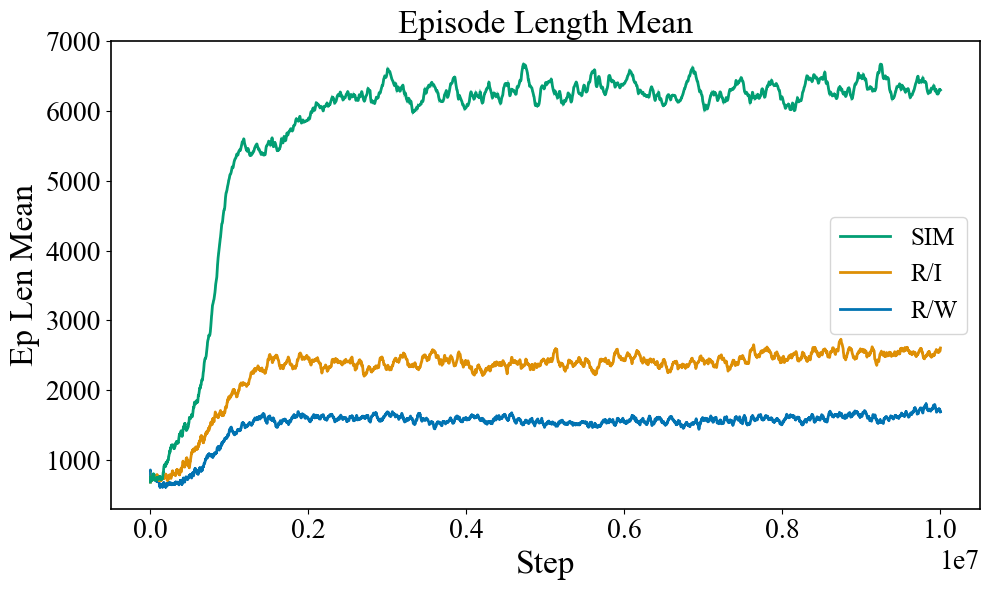

In [96]:
# keys = ["simulation", "simulation_with_real_world_input", "real_world"]

real_world_ep_len_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv"
real_world_input_ep_len_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv"
simulation_ep_len_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv"

# keys = ["C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv", \
#         "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv", \
#         "C:\\GitHub\\data_and_plot\\ep_len_mean\\simulation.csv"]

keys = [real_world_ep_len_mean, real_world_input_ep_len_mean, simulation_ep_len_mean]

legend_map = {
    real_world_ep_len_mean: "R/W",
    real_world_input_ep_len_mean: "R/I",
    simulation_ep_len_mean: "SIM",
}

# legend_map = {
#     "real_world": "Real World",
#     "simulation_with_real_world_input": "Real World Input",
#     "simulation": "Simulation",
# }

data_ep_len = {key: read_rl_csv("ep_len_mean", key) for key in keys}

plot_rl_curves(
    data_ep_len,
    legend_map=legend_map,
    title="Episode Length Mean",
    x_label="Step",
    y_label="Ep Len Mean",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system_len',
    is_legend=True,
)

## Episode Reward Mean (`ep_rew_mean`)

real csv file C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_rew_mean.csv
real csv file C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
real csv file C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
{'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_rew_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_rew_mean.csv
key: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
key: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv


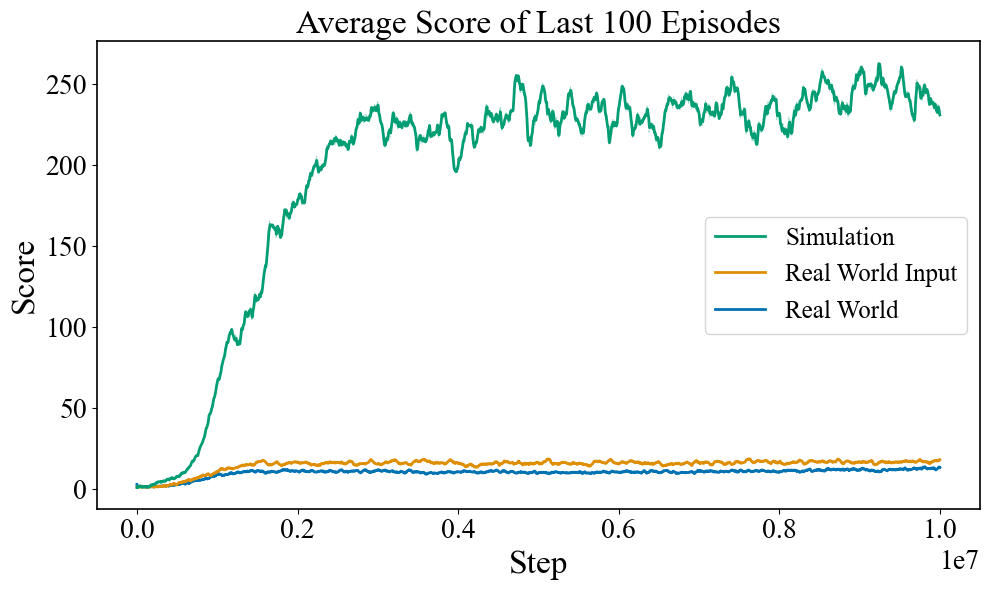

In [97]:
real_world_ep_rew_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_rew_mean.csv"
real_world_input_ep_rew_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv"
simulation_ep_rew_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv"

keys = [real_world_ep_rew_mean, real_world_input_ep_rew_mean, simulation_ep_rew_mean]

legend_map = {
    real_world_ep_rew_mean: "Real World",
    real_world_input_ep_rew_mean: "Real World Input",
    simulation_ep_rew_mean: "Simulation",
}

data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='three_system',
    is_legend=True,
)

real csv file C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_len_mean.csv
real csv file C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
{'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549)}
key: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_len_mean.csv
key: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv


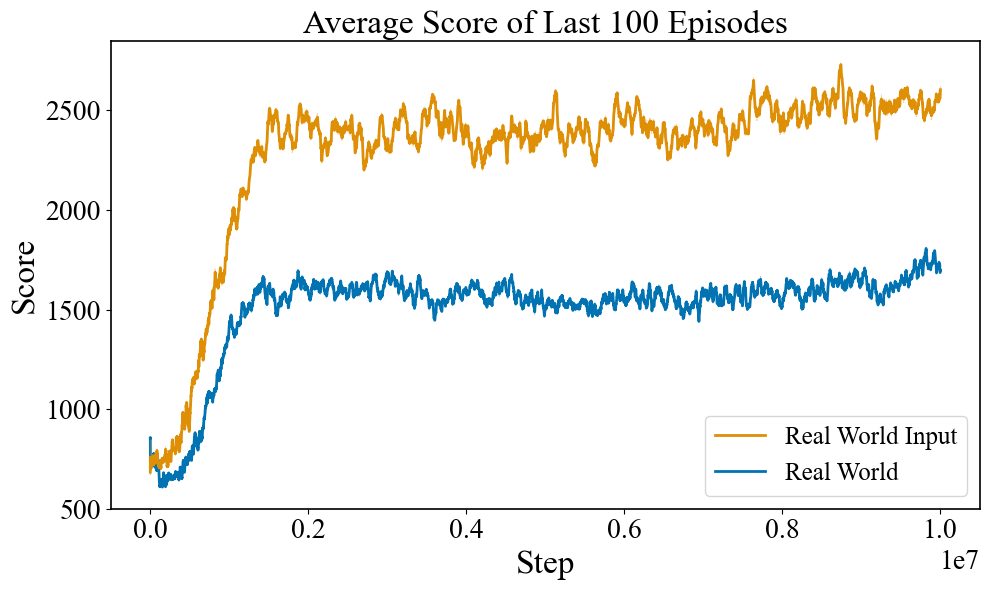

In [98]:
# keys = ["real_world", "simulation_with_real_world_input", "simulation"]
# legend_map = {
#     "real_world": "Real World",
#     "simulation_with_real_world_input": "Real World Input",
#     "simulation": "Simulation",
# }

keys = [real_world_ep_len_mean, real_world_input_ep_len_mean]

legend_map = {
    real_world_ep_len_mean: "Real World",
    real_world_input_ep_len_mean: "Real World Input",
}
# keys = ["real_world", "simulation_with_real_world_input"]
data_ep_rew = {key: read_rl_csv("ep_rew_mean", key) for key in keys}

plot_rl_curves(
    data_ep_rew,
    legend_map=legend_map,
    # colors=["green", "dodgerblue"],
    title="Average Score of Last 100 Episodes",
    x_label="Step",
    y_label="Score",
    figsize=(10, 6),
    window_size=10,
    save_path='two_system',
    is_legend=True,
    skip_color=1,
)

## Top Score (`top_score`)

real csv file C:\GitHub\data_and_plot\top_score\real_world.csv
real csv file C:\GitHub\data_and_plot\top_score\simulation_with_real_world_input.csv
real csv file C:\GitHub\data_and_plot\top_score\simulation.csv
{'C:\\GitHub\\data_and_plot\\top_score\\real_world.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\top_score\\simulation_with_real_world_input.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'C:\\GitHub\\data_and_plot\\top_score\\simulation.csv': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
key: C:\GitHub\data_and_plot\top_score\real_world.csv
key: C:\GitHub\data_and_plot\top_score\simulation_with_real_world_input.csv
key: C:\GitHub\data_and_plot\top_score\simulation.csv


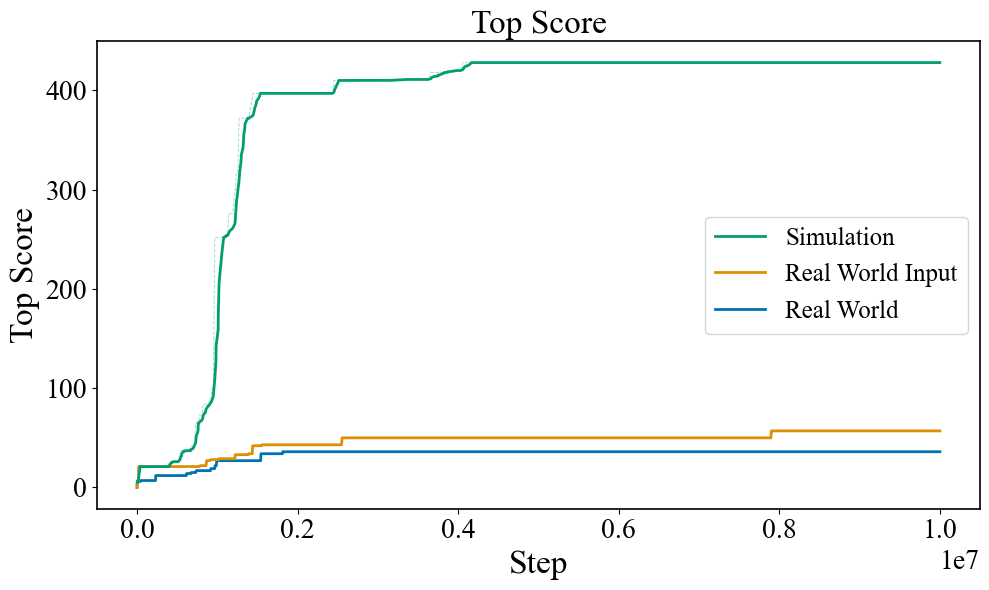

In [99]:
real_world_top_score = "C:\\GitHub\\data_and_plot\\top_score\\real_world.csv"
real_world_input_top_score = "C:\\GitHub\\data_and_plot\\top_score\\simulation_with_real_world_input.csv"
simulation_top_score = "C:\\GitHub\\data_and_plot\\top_score\\simulation.csv"

keys = [real_world_top_score, real_world_input_top_score, simulation_top_score]

legend_map = {
    real_world_top_score: "Real World",
    real_world_input_top_score: "Real World Input",
    simulation_top_score: "Simulation",
}

data_top_score = {key: read_rl_csv("top_score", key) for key in keys}

plot_rl_curves(
    data_top_score,
    legend_map=legend_map,
    title="Top Score",
    x_label="Step",
    y_label="Top Score",
    figsize=(10, 6),
    window_size=10,
    is_legend=True,
)

## Time Cost Comparison (Bar Chart)

Compare the **total wall-clock time consumed** by each setting across equal-length step intervals.

In [100]:
def plot_time_cost_bar(
    metric: str = "ep_len_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    print(f"legend_map: {legend_map}")
    print(f"legend_map keys: {list(legend_map.keys())}")
    if keys is None:
        if horizontal:
            # keys=["real_world", "simulation_with_real_world_input", "simulation"]
            keys=list(legend_map.keys())
        else:
            # keys=["simulation", "simulation_with_real_world_input", "real_world"]
            keys=list(legend_map.keys())[::-1]
        # keys = ["real_world", "simulation", "simulation_with_real_world_input"]
        # keys = ["real_world", "simulation_with_real_world_input", "simulation"]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    total_times = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        total_times[key] = (df["Wall time"].max() - df["Wall time"].min())/3600/24

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)

    values = [total_times[k] for k in keys]
    print(values)
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    if horizontal:
        bar_colors = [colors[key] for key in keys]
    else:
        bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (5, 5)
        x_label = "Days"
    else:
        figsize = (5, 5)
        y_label = "Days"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, height = 0.7, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width =0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90) 

    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    
    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()


In [101]:
def read_rl_csv_full(metric: str, key: str, base_dir: str = ".") -> pd.DataFrame:
    """Read RL CSV with Wall time, Step, Value columns."""
    # path = Path(base_dir) / metric / f"{key}.csv"
    path = f"{key}"
    print(f"read_rl_csv_full path: {path}")
    df = pd.read_csv(path)
    return df[["Wall time", "Step", "Value"]].reset_index(drop=True)

legend_map: {'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv': 'R/W', 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv': 'R/I', 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv': 'Sim'}
legend_map keys: ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv', 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv', 'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv']
key:  C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_len_mean.csv
key:  C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_len_mean.csv
key:  C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_len_me

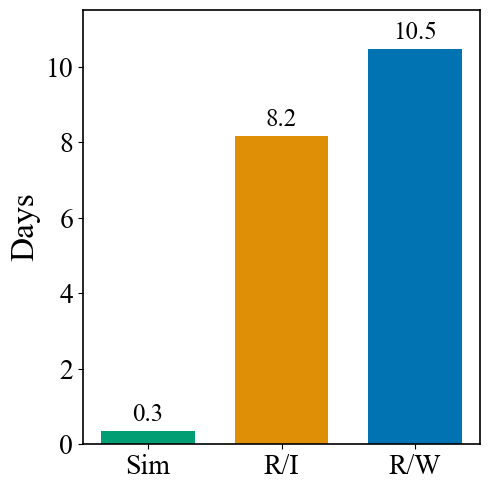

In [102]:
real_world_ep_len_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_len_mean.csv"
real_world_input_ep_len_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_len_mean.csv"
simulation_ep_len_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_len_mean.csv"

keys = [real_world_ep_len_mean, real_world_input_ep_len_mean, simulation_ep_len_mean]

legend_map = {
    real_world_ep_len_mean: "R/W",
    real_world_input_ep_len_mean: "R/I",
    simulation_ep_len_mean: "Sim",
}

plot_time_cost_bar(
    metric="ep_len_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Training Time",
    # title="Total Training Time for 10 Million Steps",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="time_cost_bar",
    horizontal = False,
)

In [103]:
def plot_maximum_score_bar(
    metric: str = "ep_rew_mean",
    keys: list = None,
    legend_map: dict = None,
    base_dir: str = ".",
    title: str = "Total Time Cost Comparison",
    # x_label: str = "Time Cost (s)",
    x_label: str = " ",
    y_label: str = " ",
    figsize: tuple = (8, 4),
    colors: list = None,
    save_path: str = None,
    dpi: int = 800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
    horizontal = True,
):
    """
    Plot a horizontal bar chart of total wall-clock time cost per setting.

    The total time is computed as:  max(Wall time) - min(Wall time).

    Args:
        metric:         which metric folder to read (only Wall time is used).
        keys:           list of file stems (settings).
        legend_map:     dict mapping key -> display label.
        base_dir:       root directory containing metric sub-folders.
        title:          chart title.
        x_label:        x-axis label.
        y_label:        y-axis label.
        figsize:        figure size (width, height) in inches.
        colors:         list of bar colours; if None, uses the style prop_cycle.
        save_path:      if given, saves the figure as <save_path>.pdf.
        dpi:            resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """
    if keys is None:
        if horizontal:
            keys=list(legend_map.keys())
        else:
            keys=list(legend_map.keys())[::-1]

    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  14)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  12)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 10)

    # Load data and compute total wall-clock time per key
    max_mean_score = {}
    for key in keys:
        print("key: ", key)
        df = read_rl_csv_full(metric, key, base_dir)
        max_mean_score[key] = df["Value"].max()

    # Resolve colors
    if colors is None:
        prop_cycle = plt.rcParams.get("axes.prop_cycle", None)
        # color_palette = sns.color_palette(color_palette, n_colors=len(algorithms)+1)
        colors = [c["color"] for c in prop_cycle] if prop_cycle else \
                 ["red", "green", "blue", "orange", "purple"]
        color_palette='colorblind'
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        colors = dict(zip(keys, color_palette))
        print(colors)
    labels = [legend_map.get(k, k) if legend_map else k for k in keys]
    print(labels)
    values = [max_mean_score[k] for k in keys]
    # bar_colors = [colors[i % len(colors)] for i in range(len(keys))]
    bar_colors = [colors[key] for key in keys][::-1]
    print(f"bar_colors: {bar_colors}")

    if horizontal:
        figsize = (8, 4)
        x_label = "Scores"
    else:
        figsize = (5, 5)
        y_label = "Scores"
    fig, ax = plt.subplots(figsize=figsize)
    # x = range(len(labels))
    if horizontal:
        bars = ax.barh(labels, values, color=bar_colors, edgecolor="white", linewidth=0.5)
        # bars = ax.barh(labels, values, color=colors, edgecolor="white", linewidth=0.5)
        ax.set_xlim(right=max(values) * 1.1)
    else:
        bars = ax.bar(labels, values, width=0.7, color=bar_colors)
        ax.bar_label(bars, padding=3, fontsize=18, fmt="%.1f")
        ax.set_ylim(top=max(values) * 1.1)
        # ax.set_xticklabels(labels, rotation=90)
        # plt.xticks(rotation=90)



    # ax.set_title(title, fontsize=_title_fs, pad=8)
    # ax.set_xlabel(x_label, fontsize=_label_fs)
    ax.set_ylabel(y_label, fontsize=_label_fs)
    # ax.tick_params(axis="x", labelsize=_tick_fs)
    ax.tick_params(axis="y", labelsize=_tick_fs)
    plt.subplots_adjust(bottom=0.05)
    

    if save_path:
        fig.savefig(f"{save_path}.pdf", dpi=dpi, bbox_inches="tight")
    fig.tight_layout()
    plt.show()

key:  C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\simulation_best_model\csv\20260610\ep_rew_mean.csv
key:  C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\10_66_28_74\csv\breakout_20260424_231658\ep_rew_mean.csv
key:  C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_rew_mean.csv
read_rl_csv_full path: C:\GitHub\data_and_plot\wgzqrmn3\csv\breakout_20260529\ep_rew_mean.csv
{'C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv': (0.00392156862745098, 0.45098039215686275, 0.6980392156862745), 'C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv': (0.8705882352941177, 0.5607843137254902, 0.0196078431372549), 'C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_rew_mean.csv': (0.00784313725490196, 0.6196078431372549, 0.45098039215686275)}
['Sim', 'R/I',

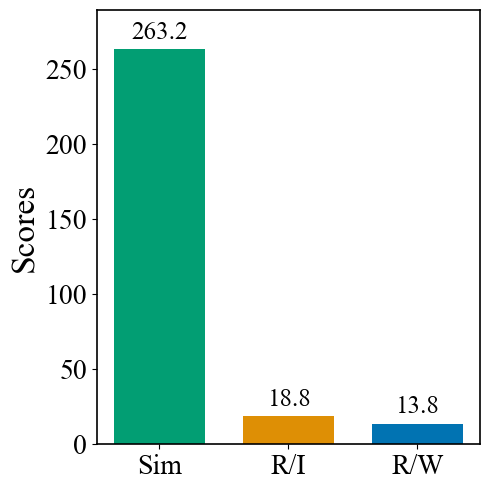

In [104]:
real_world_ep_rew_mean = "C:\\GitHub\\data_and_plot\\wgzqrmn3\\csv\\breakout_20260529\\ep_rew_mean.csv"
real_world_input_ep_rew_mean = "C:\\GitHub\\data_and_plot\\10_66_28_74\\csv\\breakout_20260424_231658\\ep_rew_mean.csv"
simulation_ep_rew_mean = "C:\\GitHub\\data_and_plot\\simulation_best_model\\csv\\20260610\\ep_rew_mean.csv"

keys = [real_world_ep_rew_mean, real_world_input_ep_rew_mean, simulation_ep_rew_mean]

legend_map = {
    real_world_ep_rew_mean: "R/W",
    real_world_input_ep_rew_mean: "R/I",
    simulation_ep_rew_mean: "Sim",
}

plot_maximum_score_bar(
    metric="ep_rew_mean",
    # keys=["real_world", "simulation_with_real_world_input", "simulation"],
    legend_map=legend_map,
    base_dir=".",
    # colors=["red", "green", "dodgerblue"],
    title="Maximum Score",
    # y_label="Days",
    # figsize=(4, 8),
    save_path="max_score_bar",
    horizontal = False,
)

## Data Processing to find the best model

In [16]:
import time
import numpy as np

from evaluation.atari_data import get_human_normalized_score, get_env_id
from evaluation import library as rly
from evaluation import metrics
from evaluation import plot_utils

import tkinter as tk

import os

import gymnasium as gym

import argparse
from distutils.util import strtobool

import ale_py
gym.register_envs(ale_py)
# gym.pprint_registry()


In [17]:
gym_id = "BreakoutNoFrameskip-v4"

In [18]:
env_id = get_env_id(gym_id)
print(f"env_id: {env_id}")

env_id: breakout


In [19]:
# files = ['./datalogs/3systems/breakout-data-dqn-model-c10_000_000.npz',
#          './datalogs/system1s0a/test_with_0s0a/breakout-data-dqn-model-9_000_000.npz']
            
# labels = ['real world system', 'real world input']

# files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-0_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-1_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-2_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-3_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-4_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-5_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-6_000_000.npz',
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-7_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-8_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-9_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result_20260517\\breakout-data-dqn-model-10_000_000.npz'] # best

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-0_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-1_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-2_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-3_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-4_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-5_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-6_000_000.npz', # best
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-7_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-8_000_000.npz', # best
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-9_000_000.npz', 
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-10_000_000.npz']

# labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_data_for_real_input_20260517\\breakout-data-dqn-model-6_000_000.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609\\breakout-data-dqn-model-_huggingface_1.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609_10\\breakout-data-dqn-model-_huggingface_2.npz']

# labels = ['6_000_000', 'huggingface_1', 'huggingface_2']

# files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609\\breakout-data-dqn-model-_huggingface_1.npz',
#          'C:\\GitHub\\data_and_plot\\10_66_28_74\\simulation\\20260609_10\\breakout-data-dqn-model-_huggingface_2.npz']

# labels = ['huggingface_1', 'huggingface_2']

files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260610\\breakout-data-dqn-model-10_000_000.npz']

# labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']
labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [21]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))
    # x_data.append(f)
    # y1_data.append(median)
    # y2_data.append(mean)
    # plt.figure(fig1.number)

    # line1.set_data(x_data, y1_data)
    # line2.set_data(x_data, y2_data)
    # ax1.set_xlim(0, max(x_data) + 1)
    # ax1.set_ylim(0, max(max(y1_data), max(y2_data)) + 10)
    # plt.draw()
    # plt.pause(0.1)
    # plt.show()
    
    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

# Save the training progress plot after all test steps are completed
# fig1.savefig("training_progress_final.pdf", dpi=300, bbox_inches='tight')
# fig3.savefig("training_progress_final3.pdf", dpi=300, bbox_inches='tight')
# print("*"*5 + " Training progress plot saved as 'training_progress_final.pdf'")

# fig, ax1 = plt.subplots()


min: -0.059027777777777776 max: 0.18402777777777776 median: -0.024305555555555552 mean: -0.003819444444444443
min: 0.04513888888888889 max: 0.670138888888889 median: 0.2534722222222222 mean: 0.26284722222222223
min: 0.0798611111111111 max: 0.670138888888889 median: 0.3229166666666667 mean: 0.34131944444444445
min: 0.04513888888888889 max: 0.7743055555555556 median: 0.2881944444444445 mean: 0.32326388888888885
min: 0.010416666666666668 max: 0.9131944444444444 median: 0.2881944444444445 mean: 0.29687500000000006
min: 0.04513888888888889 max: 0.6006944444444444 median: 0.2881944444444445 mean: 0.29513888888888895
min: 0.0798611111111111 max: 0.9479166666666666 median: 0.3229166666666667 mean: 0.34618055555555566
min: 0.04513888888888889 max: 0.8784722222222222 median: 0.2881944444444445 mean: 0.3069444444444444
min: 0.04513888888888889 max: 0.7743055555555556 median: 0.3229166666666667 mean: 0.3434027777777778
min: 0.010416666666666668 max: 0.9131944444444444 median: 0.2881944444444445 me

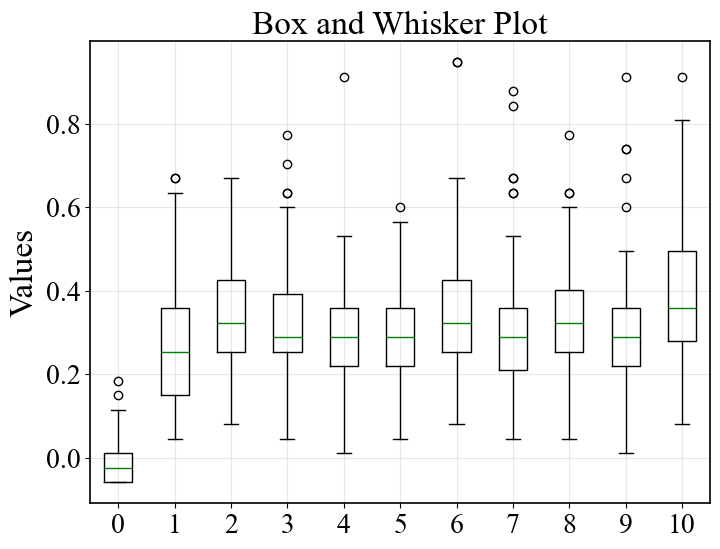

In [22]:
plt.figure(figsize=(8, 6))
# bp = plt.boxplot(list(array_for_dict), labels=labels)
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [23]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[-0.02430556 -0.01041667 -0.00381944  1.00381944]
aggregate_scores 1: 
[0.25347222 0.24583333 0.26284722 0.73715278]
aggregate_scores 2: 
[0.32291667 0.33958333 0.34131944 0.65868056]
aggregate_scores 3: 
[0.28819444 0.30277778 0.32326389 0.67673611]
aggregate_scores 4: 
[0.28819444 0.28680556 0.296875   0.703125  ]
aggregate_scores 5: 
[0.28819444 0.28819444 0.29513889 0.70486111]
aggregate_scores 6: 
[0.32291667 0.32291667 0.34618056 0.65381944]
aggregate_scores 7: 
[0.28819444 0.28194444 0.30694444 0.69305556]
aggregate_scores 8: 
[0.32291667 0.33055556 0.34340278 0.65659722]
aggregate_scores 9: 
[0.28819444 0.29097222 0.30034722 0.69965278]
aggregate_scores 10: 
[0.35763889 0.37430556 0.38715278 0.61284722]
aggregate_score_cis 0: 
[[-2.43055556e-02 -2.15277778e-02 -1.35416667e-02  9.93750000e-01]
 [ 1.04166667e-02 -6.94444444e-04  6.25000000e-03  1.01354167e+00]]
aggregate_score_cis 1: 
[[0.21875    0.21736111 0.23611111 0.709375  ]
 [0.25347222 0.275      0.29

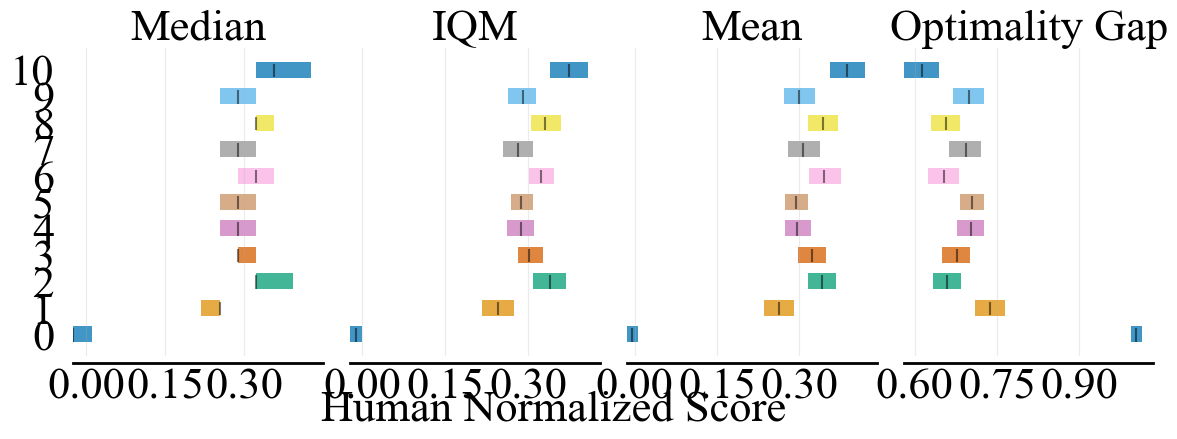

In [24]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [25]:
files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-0_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-1_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-2_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-3_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-4_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-5_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-6_000_000.npz',
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-7_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-8_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-9_000_000.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260517\\breakout-data-dqn-model-10_000_000.npz']

# labels = ['0_000_000', '1_000_000', '2_000_000', '3_000_000', '4_000_000', '5_000_000', '6_000_000', '7_000_000', '8_000_000', '9_000_000', '10_000_000']
labels = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10']

In [26]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))


min: -0.059027777777777776 max: 0.53125 median: 0.027777777777777776 mean: 0.042361111111111106
min: 0.2534722222222222 max: 1.0520833333333333 median: 0.4618055555555556 mean: 0.5069444444444445
min: 0.14930555555555555 max: 1.1562499999999998 median: 0.6006944444444444 mean: 0.621875
min: 0.2534722222222222 max: 1.2604166666666665 median: 0.6354166666666666 mean: 0.6347222222222222
min: 0.21875 max: 1.190972222222222 median: 0.6354166666666666 mean: 0.6666666666666669
min: 0.2534722222222222 max: 1.2256944444444444 median: 0.6006944444444444 mean: 0.6409722222222223
min: 0.21875 max: 1.4340277777777777 median: 0.670138888888889 mean: 0.6788194444444444
min: 0.2534722222222222 max: 1.2256944444444444 median: 0.5659722222222222 mean: 0.5746527777777778
min: 0.2881944444444445 max: 1.503472222222222 median: 0.670138888888889 mean: 0.6909722222222224
min: 0.2534722222222222 max: 1.2256944444444444 median: 0.6354166666666666 mean: 0.6538194444444444
min: 0.2534722222222222 max: 1.39930555

C:\Users\rongp\AppData\Local\Temp\ipykernel_37096\2254188213.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(list(array_for_dict), labels=labels)


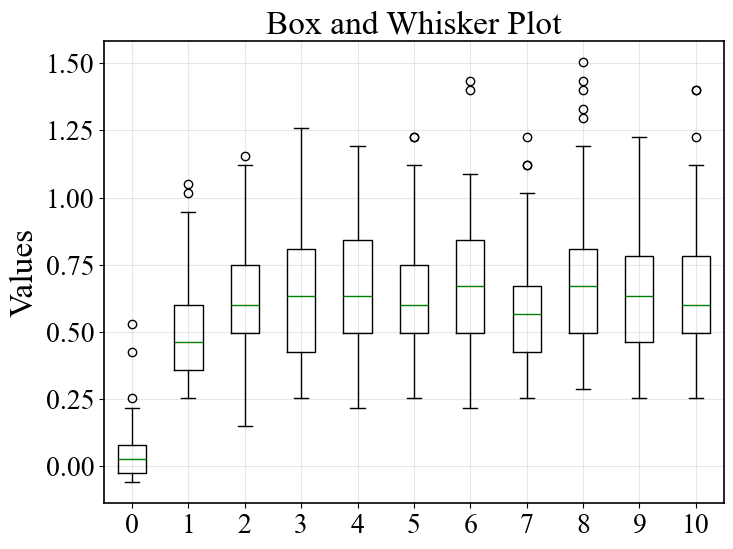

In [27]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [28]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[0.02777778 0.03055556 0.04236111 0.95763889]
aggregate_scores 1: 
[0.46180556 0.47638889 0.50694444 0.49375   ]
aggregate_scores 2: 
[0.60069444 0.61319444 0.621875   0.38194444]
aggregate_scores 3: 
[0.63541667 0.61111111 0.63472222 0.37569444]
aggregate_scores 4: 
[0.63541667 0.65625    0.66666667 0.33993056]
aggregate_scores 5: 
[0.60069444 0.60833333 0.64097222 0.36770833]
aggregate_scores 6: 
[0.67013889 0.65555556 0.67881944 0.3328125 ]
aggregate_scores 7: 
[0.56597222 0.55416667 0.57465278 0.43020833]
aggregate_scores 8: 
[0.67013889 0.65138889 0.69097222 0.33489583]
aggregate_scores 9: 
[0.63541667 0.62777778 0.65381944 0.35815972]
aggregate_scores 10: 
[0.60069444 0.61111111 0.65       0.36180556]
aggregate_score_cis 0: 
[[0.01041667 0.01319444 0.025      0.93854167]
 [0.04513889 0.04722222 0.06145833 0.975     ]]
aggregate_score_cis 1: 
[[0.42708333 0.43819444 0.47256944 0.45850694]
 [0.53125    0.51597222 0.54270833 0.52760417]]
aggregate_score_cis 2: 


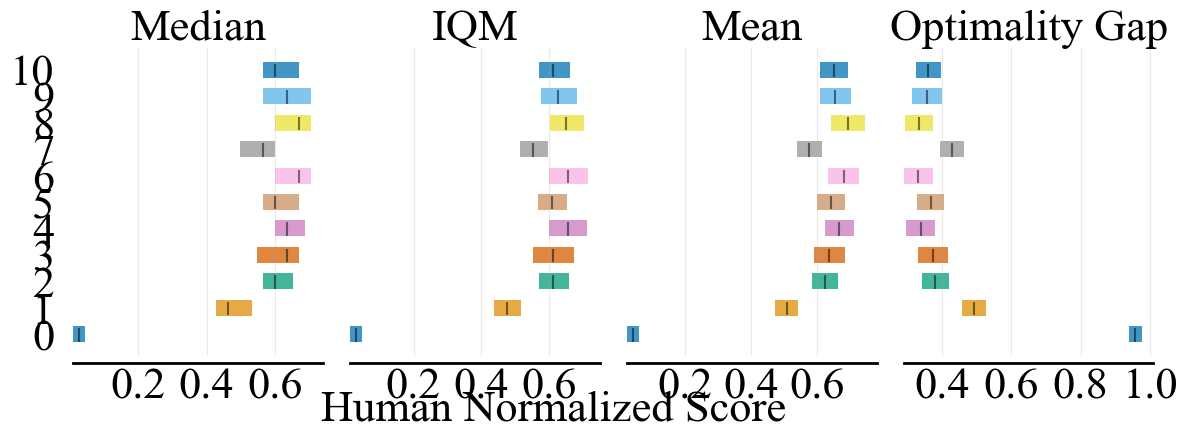

In [29]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [31]:
files = ['C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-random_0.npz', 
         'C:\\GitHub\\data_and_plot\\10_66_28_74\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-best-model_1.npz']

labels = ['0', '1']

In [32]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.3229166666666667 median: -0.024305555555555552 mean: -0.007986111111111109
min: -0.059027777777777776 max: 0.3923611111111111 median: 0.010416666666666668 mean: 0.031597222222222235


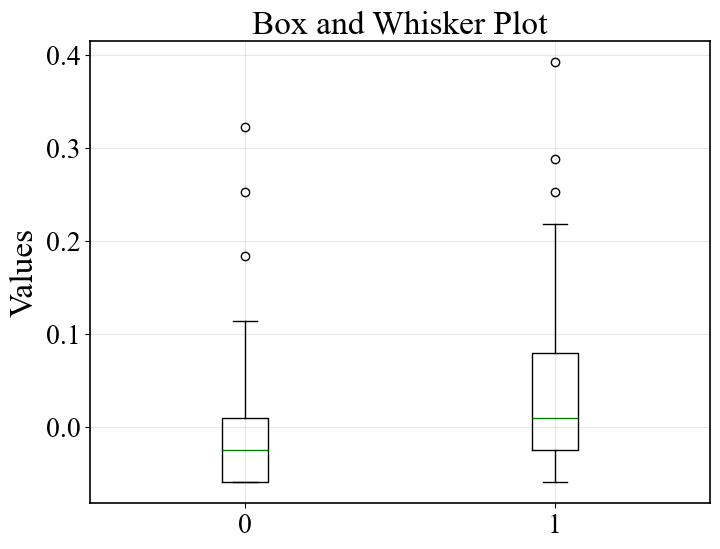

In [33]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [34]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[-0.02430556 -0.02569444 -0.00798611  1.00798611]
aggregate_scores 1: 
[0.01041667 0.00625    0.03159722 0.96840278]
aggregate_score_cis 0: 
[[-0.02430556 -0.03680556 -0.02013889  0.99444444]
 [-0.02430556 -0.0125      0.00555556  1.02013889]]
aggregate_score_cis 1: 
[[-0.02430556 -0.00694444  0.01527778  0.95034722]
 [ 0.01041667  0.02361111  0.04965278  0.98472222]]
***** Available algorithms for plotting:  ['0', '1']


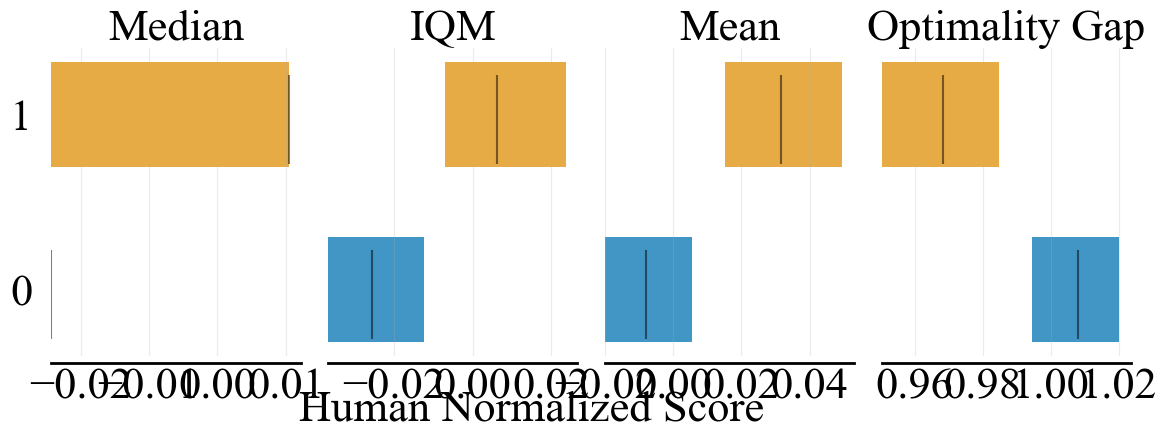

In [35]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [36]:
files = ['C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-random_0.npz', 
         'C:\\GitHub\\data_and_plot\\wgzqrmn3\\test_result\\20260611_sim_best_model\\breakout-data-dqn-model-best-model_1.npz']

labels = ['0', '1']

In [37]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.11458333333333333 median: -0.024305555555555552 mean: -0.014583333333333335
min: -0.059027777777777776 max: 0.11458333333333333 median: 0.010416666666666668 mean: -0.005902777777777779


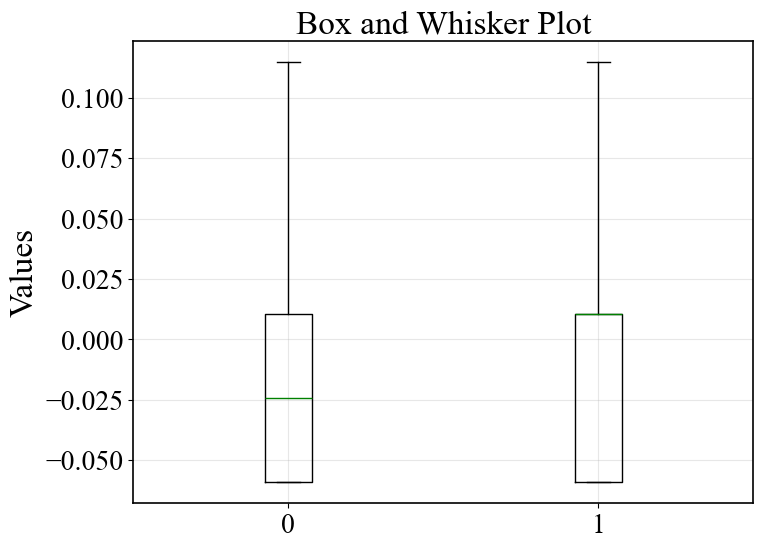

In [38]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [39]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[-0.02430556 -0.02222222 -0.01458333  1.01458333]
aggregate_scores 1: 
[ 0.01041667 -0.00625    -0.00590278  1.00590278]
aggregate_score_cis 0: 
[[-0.02430556 -0.03402778 -0.02291667  1.00590278]
 [-0.02430556 -0.01041667 -0.00590278  1.02291667]]
aggregate_score_cis 1: 
[[ 0.01041667 -0.01875    -0.01458333  0.99722222]
 [ 0.01041667  0.00972222  0.00277778  1.01458333]]
***** Available algorithms for plotting:  ['0', '1']


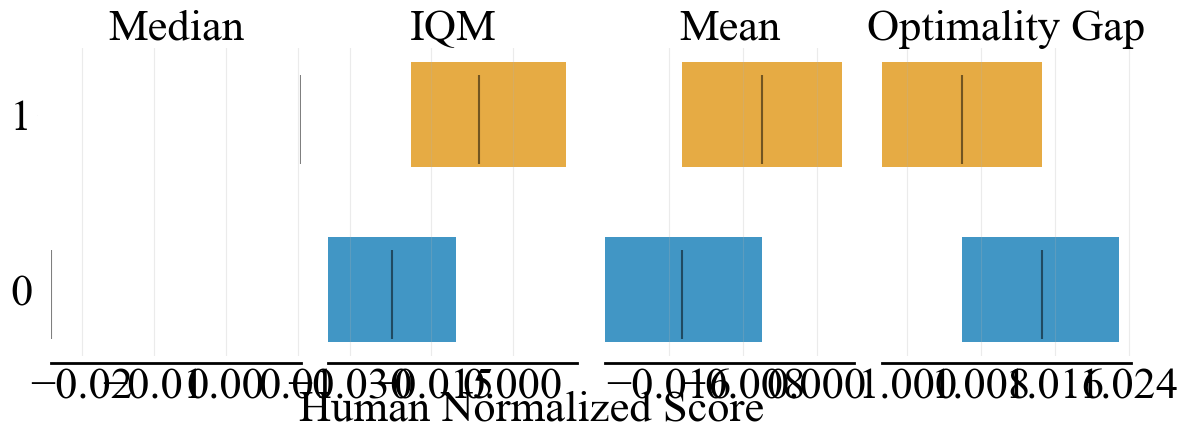

In [40]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

In [41]:
files = ['C:\\GitHub\\data_and_plot\\simulation_best_model\\test_result\\20260611\\breakout-data-dqn-model-random_0.npz', 
         'C:\\GitHub\\data_and_plot\\simulation_best_model\\test_result\\20260611\\breakout-data-dqn-model-best-model_1.npz']

labels = ['0', '1']

In [42]:
f = 0

for file_path in files:
    
    f += 1
    
    # Load the existing data from the .npz file
    loaded_data = np.load(file_path)
    
    # Retrieve the existing array and datetime
    raw_scores = loaded_data['array']
    existing_array = np.array([get_human_normalized_score(env_id, score) for score in raw_scores])
    if len(existing_array) == 101:
        existing_array = existing_array[:-1]
        # existing_array = existing_array[1:]
    # print(f"{file_path} Existing array: {existing_array}")
    csvfile = file_path.split('/')[-1].replace('.npz', '.csv')
    np.savetxt(csvfile, existing_array.reshape(-1, 1), delimiter=",")

    min_score = existing_array.min()
    max_score = existing_array.max()
    median = np.median(existing_array)
    mean = np.mean(existing_array)
    
    print("min: " + str(min_score) + " max: " + str(max_score) + " median: " + str(median) + " mean: " + str(mean))

    if f == 1:
        array_for_dict = existing_array
    else:
        array_for_dict = np.vstack((array_for_dict, existing_array))

min: -0.059027777777777776 max: 0.18402777777777776 median: -0.024305555555555552 mean: -0.02083333333333333
min: 7.40625 max: 13.48263888888889 median: 11.60763888888889 mean: 11.320486111111114


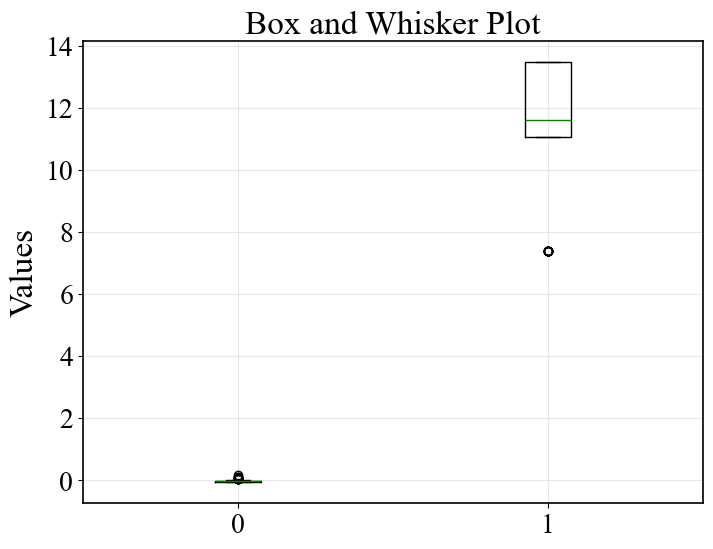

In [43]:
plt.figure(figsize=(8, 6))
bp = plt.boxplot(list(array_for_dict), tick_labels=labels)
plt.ylabel('Values')
plt.title('Box and Whisker Plot')
plt.grid(True, alpha=0.3)
plt.draw()
 
plt.pause(0.1)
plt.show()

In [44]:
hns_dict = {}

for i in range(min(len(labels), array_for_dict.shape[0])):
    # The evaluation library expects 2D arrays: [num_runs, num_tasks]
    # array_for_dict[i] is 1D (101 scores from 101 test episodes)
    # We need to reshape it to 2D: [101 runs, 1 task] for single-task evaluation
    # print(f"Original shape of array_for_dict[{i}]: {array_for_dict[i].shape}")
    scores_2d = np.array(array_for_dict[i]).reshape(-1, 1)  # Convert 1D to 2D
    # print(f"Reshaped scores_2d for {labels[i]}: {scores_2d.shape}")
    # scores_2d = np.array(array_for_dict[i]).reshape(1, -1)  # Convert 1D to 2D
    hns_dict[labels[i]] = scores_2d
    # hns_dict[labels[i]] = array_for_dict[i]

# for key, value in hns_dict.items():
#     print(f"{key}: ")
#     print(f"{value}")

aggregate_scores 0: 
[-0.02430556 -0.03263889 -0.02083333  1.02083333]
aggregate_scores 1: 
[11.60763889 11.60763889 11.32048611  0.        ]
aggregate_score_cis 0: 
[[-0.02430556 -0.03958333 -0.02951389  1.01145833]
 [-0.02430556 -0.02430556 -0.01145833  1.02951389]]
aggregate_score_cis 1: 
[[11.08680556 11.32289931 10.91699653  0.        ]
 [11.60763889 12.01805556 11.70833333  0.        ]]
***** Available algorithms for plotting:  ['0', '1']


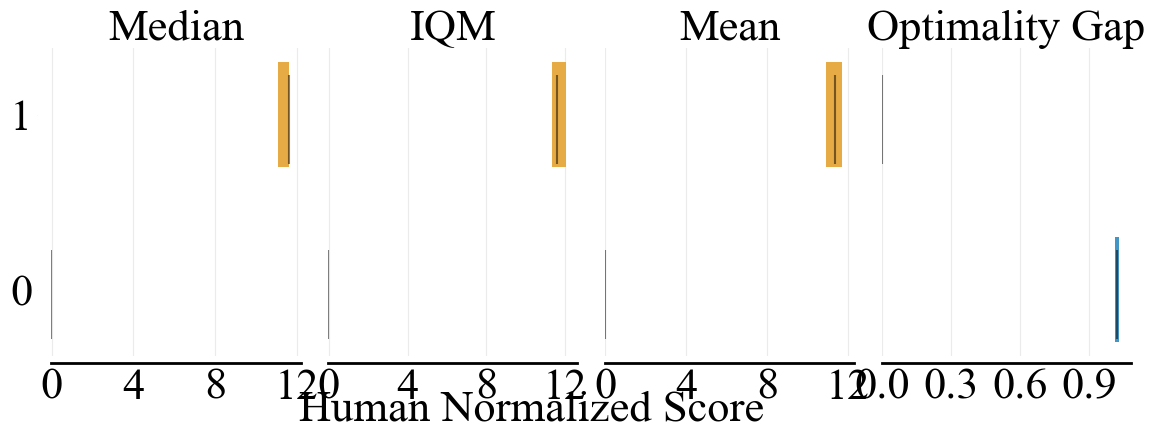

In [45]:
aggregate_func = lambda x: np.array([
    metrics.aggregate_median(x),
    metrics.aggregate_iqm(x),
    metrics.aggregate_mean(x),
    metrics.aggregate_optimality_gap(x)])
    
aggregate_scores, aggregate_score_cis = rly.get_interval_estimates(hns_dict, aggregate_func, reps=50000)

for key, value in aggregate_scores.items():
    print(f"aggregate_scores {key}: ")
    print(f"{value}")

for key, value in aggregate_score_cis.items():
    print(f"aggregate_score_cis {key}: ")
    print(f"{value}")        

# Use only the algorithms that actually have data
available_algorithms = list(hns_dict.keys())
print("*"*5 + " Available algorithms for plotting: ", available_algorithms)

fig2, ax2 = plot_utils.plot_interval_estimates(
    aggregate_scores,
    aggregate_score_cis,
    metric_names=['Median', 'IQM', 'Mean', 'Optimality Gap'],
    algorithms=available_algorithms,
    xlabel_y_coordinate=-0.05,
    xlabel='Human Normalized Score')

fig2.set_size_inches(12, 4)

plt.figure(fig2.number)

fig2.savefig("hns_all_data.pdf", dpi=300, bbox_inches='tight')

plt.pause(0.1)
plt.show()

## Three Systems Comparison — Interval Estimates (Median / IQM / Mean)

In [55]:
# ── Plotting function ────────────────────────────────────────────────────────
def plot_existing_data_interval_estimates(
    point_estimates,
    interval_estimates,
    metric='Median',
    legend_map=legend_map,
    system_order=None,
    colours=None,
    figsize=(6.0, 2.6),
    bar_height=0.45,
    n_resamples=10_000,
    ci=0.95,
    save_path=None,
    dpi=800,
    fontsize_title=None,
    fontsize_label=None,
    fontsize_tick=None,
):
    """
    Plot a single interval-estimate bar chart for one statistic (Median / IQM / Mean).
    Font sizes fall back to rcParams values when not explicitly provided.

    Args:
        hns_scores:    dict mapping system label -> 1-D numpy array of HNS values.
        metric:        statistic to display: 'Median', 'IQM', or 'Mean'.
        system_order:  list of labels in display order (top to bottom).
                       Defaults to hns_scores.keys().
        colours:       dict mapping label -> colour string. Defaults to built-in palette.
        figsize:       figure size (width, height) in inches.
        bar_height:    height of each CI bar (0–1).
        n_resamples:   bootstrap resamples for CI estimation.
        ci:            confidence level, e.g. 0.95 for 95% CI.
        save_path:     if given, saves figure as <save_path>.pdf.
        dpi:           resolution for saved figure.
        fontsize_title: title font size (default: rcParams axes.titlesize).
        fontsize_label: x-axis label font size (default: rcParams axes.labelsize).
        fontsize_tick:  tick label font size (default: rcParams xtick.labelsize).
    """

    keys=['real world system', 'real world input', 'simulation']
    _title_fs = fontsize_title or plt.rcParams.get("axes.titlesize",  22)
    _label_fs = fontsize_label or plt.rcParams.get("axes.labelsize",  22)
    _tick_fs  = fontsize_tick  or plt.rcParams.get("xtick.labelsize", 22)

    _DEFAULT_COLOURS = {
        'simulation':        '#2BAAAB',
        'real world input':  '#E8A817',
        'real world system': '#3A88C5',
    }
    if colours is None:
        colours = _DEFAULT_COLOURS
        color_palette='colorblind'
        # color_palette = sns.color_palette(color_palette, n_colors=len(hns_scores.keys()))
        color_palette = sns.color_palette(color_palette, n_colors=len(keys))
        # colours = dict(zip(hns_scores.keys(), color_palette))
        colours = dict(zip(keys, color_palette))
    if system_order is None:
        system_order = list(hns_scores.keys())

    fig, ax = plt.subplots(figsize=figsize)

    for yi, label in enumerate(system_order):
        pt = point_estimates[label]
        lo, hi = interval_estimates[label]
        color = colours.get(label, 'steelblue')

        ax.barh(yi, hi - lo, left=lo, height=bar_height,
                color=color, alpha=0.85, linewidth=0)
        ax.plot([pt, pt], [yi - bar_height / 2, yi + bar_height / 2],
                color='black', linewidth=1.8, solid_capstyle='round')

    print("legend_map: ", legend_map)
    print("keys :", keys)

    labels = list(legend_map.values())
    print("labels: ", labels)
    ax.set_yticks(range(len(system_order)))
    # ax.set_yticklabels(system_order, fontsize=_tick_fs)
    ax.set_yticklabels(labels, fontsize=_tick_fs)
    # ax.set_xlabel('Human Normalized Score', fontsize=_label_fs)
    # ax.set_title(metric, fontsize=_title_fs, pad=6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(axis='y', length=0)
    ax.tick_params(axis='x', labelsize=_tick_fs)
    ax.grid(axis='x', linestyle='--', linewidth=0.6, alpha=0.5)

    if save_path:
        fig.savefig(f'{save_path}.pdf', dpi=dpi, bbox_inches='tight')
    fig.tight_layout()
    plt.show()


In [56]:
aggregate_scores = {
    "real world system": np.array([0.35763889, 0.37430556, 0.38715278, 0.61284722]), 
    "real world input": np.array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 
    "simulation": np.array([11.60763889, 11.60763889, 11.32048611,  0.])}
aggregate_score_cis = {
        "real world system": np.array([[0.32291667, 0.33958333, 0.35590278, 0.58055556   ],
                                       [0.42708333, 0.40833333, 0.41944444, 0.64409722]]), 
        "real world input": np.array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
                                      [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 
        "simulation": np.array([[11.08680556, 11.32289931, 10.91699653, 0.],
                                [11.60763889, 12.01805556, 11.70833333, 0.]])}

In [57]:
SYSTEM_ORDER = ['real world system', 'real world input', 'simulation']
legend_map = {
    "real world system": "R/W",
    "real world input": "R/I",
    "simulation": "Sim",
}

In [58]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.35763889]), 'real world input': array([0.67013889]), 'simulation': array([11.60763889])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.32291667],
       [0.42708333]]), 'real world input': array([[0.60069444],
       [0.70486111]]), 'simulation': array([[11.08680556],
       [11.60763889]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'R/I', 'Sim']


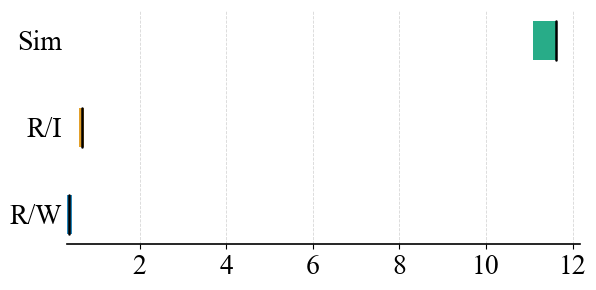

In [59]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_median',
)

In [60]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.37430556]), 'real world input': array([0.65138889]), 'simulation': array([11.60763889])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.33958333],
       [0.40833333]]), 'real world input': array([[0.60347222],
       [0.70416667]]), 'simulation': array([[11.32289931],
       [12.01805556]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'R/I', 'Sim']


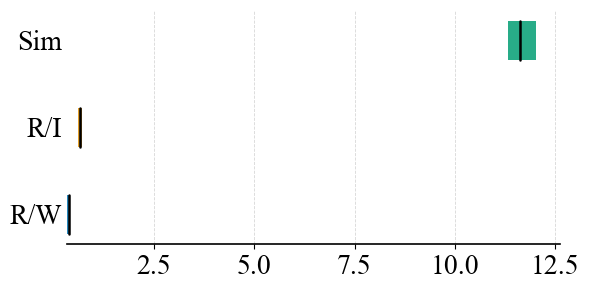

In [61]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_iqm',
)

In [62]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.38715278]), 'real world input': array([0.69097222]), 'simulation': array([11.32048611])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.35590278],
       [0.41944444]]), 'real world input': array([[0.64201389],
       [0.74271701]]), 'simulation': array([[10.91699653],
       [11.70833333]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'R/I', 'Sim']


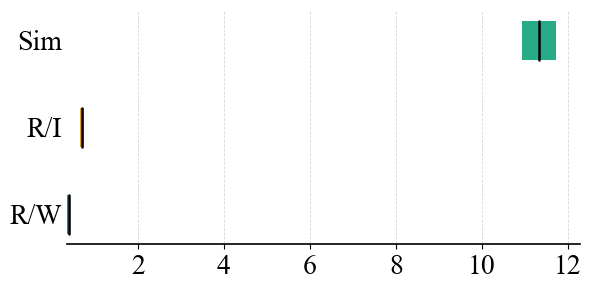

In [63]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_mean',
)

In [64]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.61284722]), 'real world input': array([0.33489583]), 'simulation': array([0.])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.58055556],
       [0.64409722]]), 'real world input': array([[0.29513889],
       [0.37430556]]), 'simulation': array([[0.],
       [0.]])}


legend_map:  {'real world system': 'R/W', 'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'R/I', 'Sim']


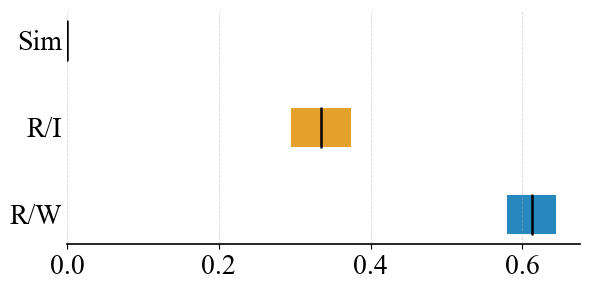

In [65]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='three_systems_optimality_gap',
)

In [70]:
aggregate_scores = {
    "real world input": np.array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 
    "simulation": np.array([0.01041667, 0.00625,    0.03159722, 0.96840278])}
aggregate_score_cis = {
        "real world input": np.array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
                                      [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 
        "simulation": np.array([[-0.02430556, -0.00694444,  0.01527778,  0.95034722],
                                [0.01041667,  0.02361111,  0.04965278,  0.98472222]])}
print(f"aggregate_scores: type: {type(aggregate_scores)}, data: {aggregate_scores}")
print(f"aggregate_scores: type: {type(aggregate_score_cis)}, data: {aggregate_score_cis}")

aggregate_scores: type: <class 'dict'>, data: {'real world input': array([0.67013889, 0.65138889, 0.69097222, 0.33489583]), 'simulation': array([0.01041667, 0.00625   , 0.03159722, 0.96840278])}
aggregate_scores: type: <class 'dict'>, data: {'real world input': array([[0.60069444, 0.60347222, 0.64201389, 0.29513889],
       [0.70486111, 0.70416667, 0.74271701, 0.37430556]]), 'simulation': array([[-0.02430556, -0.00694444,  0.01527778,  0.95034722],
       [ 0.01041667,  0.02361111,  0.04965278,  0.98472222]])}


In [71]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")


aggregate_scores_median: type: <class 'dict'>, data: {'real world input': array([0.67013889]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world input': array([[0.60069444],
       [0.70486111]]), 'simulation': array([[-0.02430556],
       [ 0.01041667]])}


In [72]:
SYSTEM_ORDER = ['real world input', 'simulation']
legend_map = {
    "real world input": "R/I",
    "simulation": "Sim",
}

legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/I', 'Sim']


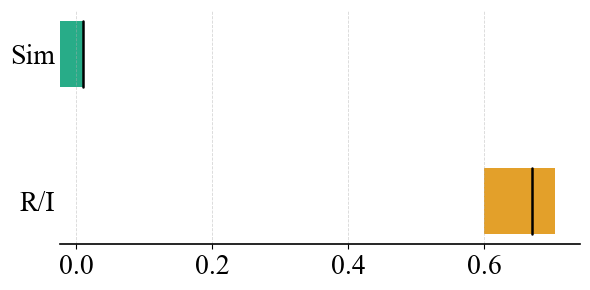

In [73]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_median',
)

In [74]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world input': array([0.65138889]), 'simulation': array([0.00625])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world input': array([[0.60347222],
       [0.70416667]]), 'simulation': array([[-0.00694444],
       [ 0.02361111]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/I', 'Sim']


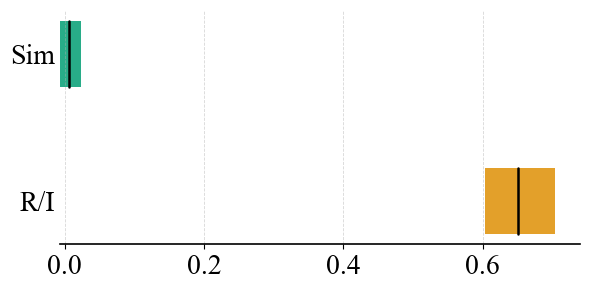

In [75]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_iqm',
)

In [76]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world input': array([0.69097222]), 'simulation': array([0.03159722])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world input': array([[0.64201389],
       [0.74271701]]), 'simulation': array([[0.01527778],
       [0.04965278]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/I', 'Sim']


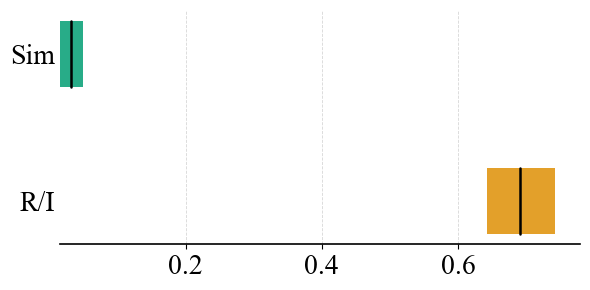

In [77]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_mean',
)

In [78]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world input': array([0.33489583]), 'simulation': array([0.96840278])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world input': array([[0.29513889],
       [0.37430556]]), 'simulation': array([[0.95034722],
       [0.98472222]])}


legend_map:  {'real world input': 'R/I', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/I', 'Sim']


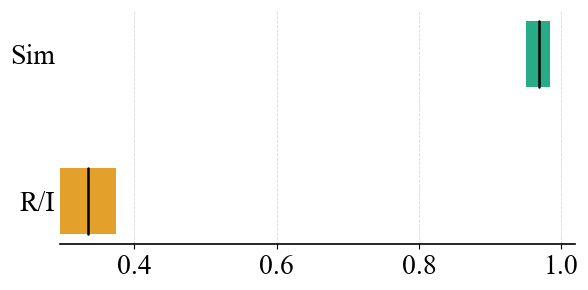

In [79]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='two_systems_optimality_gap',
)

In [80]:
aggregate_scores = {
    "real world system": np.array([0.35763889, 0.37430556, 0.38715278, 0.61284722]), 
    "simulation": np.array([0.01041667, -0.00625,    -0.00590278,  1.00590278])}
aggregate_score_cis = {
        "real world system": np.array([[0.32291667, 0.33958333, 0.35590278, 0.58055556   ],
                                       [0.42708333, 0.40833333, 0.41944444, 0.64409722]]), 
        "simulation": np.array([[0.01041667, -0.01875,    -0.01458333,  0.99722222],
                                [0.01041667,  0.00972222,  0.00277778,  1.01458333]])}

In [81]:
SYSTEM_ORDER = ['real world system', 'simulation']
legend_map = {
    "real world system": "R/W",
    "simulation": "Sim",
}

In [82]:
aggregate_scores_median = {key: value[0:1] for key, value in aggregate_scores.items()}
aggregate_score_cis_median = {key: value[:, 0:1]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_median: type: {type(aggregate_scores_median)}, data: {aggregate_scores_median}")
print(f"aggregate_score_cis_median: type: {type(aggregate_score_cis_median)}, data: {aggregate_score_cis_median}")

aggregate_scores_median: type: <class 'dict'>, data: {'real world system': array([0.35763889]), 'simulation': array([0.01041667])}
aggregate_score_cis_median: type: <class 'dict'>, data: {'real world system': array([[0.32291667],
       [0.42708333]]), 'simulation': array([[0.01041667],
       [0.01041667]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'Sim']


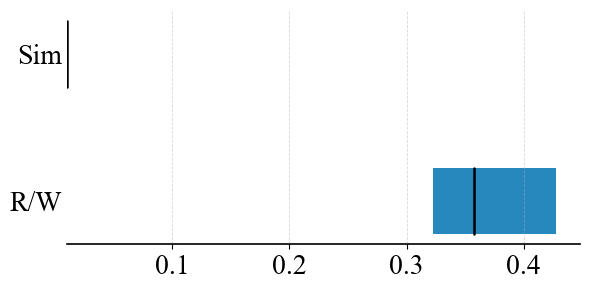

In [83]:
plot_existing_data_interval_estimates(
    aggregate_scores_median,
    aggregate_score_cis_median,
    metric='Median',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_median',
)

In [84]:
aggregate_scores_iqm = {key: value[1:2] for key, value in aggregate_scores.items()}
aggregate_score_cis_iqm = {key: value[:, 1:2]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_iqm: type: {type(aggregate_scores_iqm)}, data: {aggregate_scores_iqm}")
print(f"aggregate_score_cis_iqm: type: {type(aggregate_score_cis_iqm)}, data: {aggregate_score_cis_iqm}")

aggregate_scores_iqm: type: <class 'dict'>, data: {'real world system': array([0.37430556]), 'simulation': array([-0.00625])}
aggregate_score_cis_iqm: type: <class 'dict'>, data: {'real world system': array([[0.33958333],
       [0.40833333]]), 'simulation': array([[-0.01875   ],
       [ 0.00972222]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'Sim']


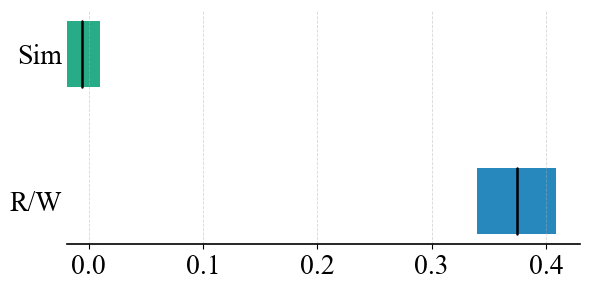

In [85]:
plot_existing_data_interval_estimates(
    aggregate_scores_iqm,
    aggregate_score_cis_iqm,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_iqm',
)

In [86]:
aggregate_scores_mean = {key: value[2:3] for key, value in aggregate_scores.items()}
aggregate_score_cis_mean = {key: value[:, 2:3]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_mean: type: {type(aggregate_scores_mean)}, data: {aggregate_scores_mean}")
print(f"aggregate_score_cis_mean: type: {type(aggregate_score_cis_mean)}, data: {aggregate_score_cis_mean}")

aggregate_scores_mean: type: <class 'dict'>, data: {'real world system': array([0.38715278]), 'simulation': array([-0.00590278])}
aggregate_score_cis_mean: type: <class 'dict'>, data: {'real world system': array([[0.35590278],
       [0.41944444]]), 'simulation': array([[-0.01458333],
       [ 0.00277778]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'Sim']


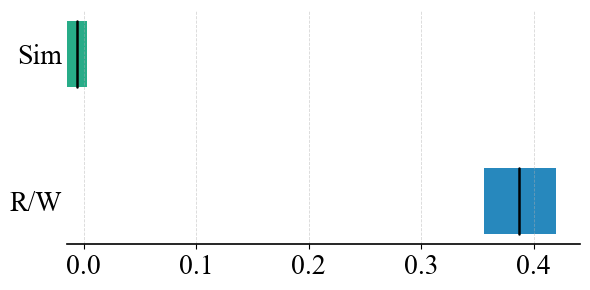

In [87]:
plot_existing_data_interval_estimates(
    aggregate_scores_mean,
    aggregate_score_cis_mean,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_mean',
)

In [88]:
aggregate_scores_optimality_gap = {key: value[3:4] for key, value in aggregate_scores.items()}
aggregate_score_cis_optimality_gap = {key: value[:, 3:4]  for key, value in aggregate_score_cis.items()}

print(f"aggregate_scores_optimality_gap: type: {type(aggregate_scores_optimality_gap)}, data: {aggregate_scores_optimality_gap}")
print(f"aggregate_score_cis_optimality_gap: type: {type(aggregate_score_cis_optimality_gap)}, data: {aggregate_score_cis_optimality_gap}")

aggregate_scores_optimality_gap: type: <class 'dict'>, data: {'real world system': array([0.61284722]), 'simulation': array([1.00590278])}
aggregate_score_cis_optimality_gap: type: <class 'dict'>, data: {'real world system': array([[0.58055556],
       [0.64409722]]), 'simulation': array([[0.99722222],
       [1.01458333]])}


legend_map:  {'real world system': 'R/W', 'simulation': 'Sim'}
keys : ['real world system', 'real world input', 'simulation']
labels:  ['R/W', 'Sim']


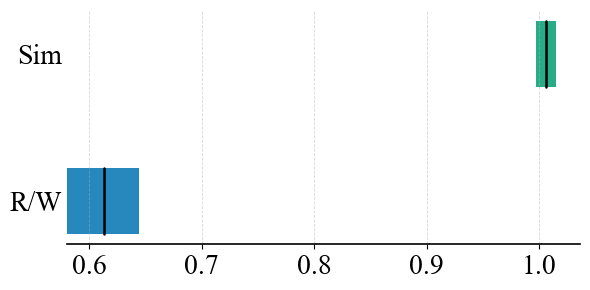

In [89]:
plot_existing_data_interval_estimates(
    aggregate_scores_optimality_gap,
    aggregate_score_cis_optimality_gap,
    metric='Optimality Gap',
    system_order=SYSTEM_ORDER,
    legend_map=legend_map,
    figsize=(6, 3),
    save_path='real_world_optimality_gap',
)

In [ ]:
# Breakout: random ≈ 1.7, human ≈ 30.5
RANDOM_SCORE = 1.7
HUMAN_SCORE  = 30.5

# _3systems_files = {
#     'real world system': './datalogs/3systems/breakout-data-dqn-model-r10_000_000.npz',
#     'real world input':  './datalogs/3systems/breakout-data-dqn-model-c10_000_000.npz',
#     'simulation':        './datalogs/3systems/breakout-data-dqn-model-s10_000_000.npz',
# }

_3systems_files = {
    'real world system': './datalogs/recent/breakout-data-dqn-model-rw.npz',
    'real world input':  './datalogs/recent/breakout-data-dqn-model-ri.npz',
    'simulation':        './datalogs/recent/breakout-data-dqn-model-sim.npz',
}

hns_scores = load_hns_scores(_3systems_files, RANDOM_SCORE, HUMAN_SCORE)

for lbl, arr in hns_scores.items():
    print(f"{lbl:25s}: n={len(arr):3d}  mean={arr.mean():.3f}  median={np.median(arr):.3f}")

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='IQM',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_iqm',
)

In [ ]:
plot_interval_estimates(
    hns_scores,
    metric='Mean',
    system_order=SYSTEM_ORDER,
    figsize=(10, 6),
    save_path='three_systems_mean',
)
